# สำรวจข้อมูล NHANES 2017-2018

เริ่มจากดูข้อมูล 3 ไฟล์ที่โหลดมา คือ DEMO (อายุ เพศ), BMX (ค่าวัดร่างกาย) และ DXX (ผลสแกน DXA)

## 1. โหลดข้อมูลดิบ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RAW = "../data/raw"
df_demo = pd.read_sas(f"{RAW}/DEMO_J.XPT")
df_bmx = pd.read_sas(f"{RAW}/BMX_J.XPT")
df_dxa = pd.read_sas(f"{RAW}/DXX_J.xpt")

print("DEMO", df_demo.shape, "| BMX", df_bmx.shape, "| DXA", df_dxa.shape)

DEMO (9254, 46) | BMX (8704, 21) | DXA (5114, 93)


## 2. Demographics (DEMO_J)

In [2]:
key = ["SEQN", "RIDAGEYR", "RIAGENDR"]
print(df_demo[key].head(), "\n")
print("missing\n", df_demo[key].isna().sum(), "\n")
print(df_demo["RIDAGEYR"].describe(), "\n")
print(df_demo["RIAGENDR"].value_counts())

      SEQN  RIDAGEYR  RIAGENDR
0  93703.0       2.0       2.0
1  93704.0       2.0       1.0
2  93705.0      66.0       2.0
3  93706.0      18.0       1.0
4  93707.0      13.0       1.0 

missing
 SEQN        0
RIDAGEYR    0
RIAGENDR    0
dtype: int64 

count    9.254000e+03
mean     3.433423e+01
std      2.550028e+01
min      5.397605e-79
25%      1.100000e+01
50%      3.100000e+01
75%      5.800000e+01
max      8.000000e+01
Name: RIDAGEYR, dtype: float64 

RIAGENDR
2.0    4697
1.0    4557
Name: count, dtype: int64


อายุต่ำสุดออกมาเป็น 5.4e-79 ดูแปลกๆ เลยลองดูแถวที่อายุต่ำกว่า 1 ปี

In [3]:
infants = df_demo["RIDAGEYR"] < 1
print(df_demo.loc[infants, ["SEQN", "RIDAGEYR", "RIDAGEMN", "RIDEXAGM"]].head())
print(f"\nทารกอายุต่ำกว่า 1 ปี {infants.sum()} คน = {infants.mean() * 100:.2f}% ของ sample")

        SEQN      RIDAGEYR  RIDAGEMN  RIDEXAGM
7    93710.0  5.397605e-79      11.0      13.0
45   93748.0  5.397605e-79       7.0       8.0
83   93786.0  5.397605e-79       3.0       NaN
151  93854.0  5.397605e-79       8.0       8.0
162  93865.0  5.397605e-79       4.0       4.0

ทารกอายุต่ำกว่า 1 ปี 357 คน = 3.86% ของ sample


ไม่ได้เป็นข้อมูลผิด NHANES เก็บอายุของทารกเป็นเดือนไว้อีกคอลัมน์ ค่านี้เลยเป็นแค่เศษทศนิยม

จะใช้เฉพาะผู้ใหญ่ 18-59 ปี เพราะเด็กกับผู้สูงอายุมีร่างกายต่างจากวัยทำงานค่อนข้างมาก

## 3. Body Measures (BMX_J)

In [4]:
bm = ["BMXWT", "BMXHT", "BMXBMI"]
print("missing\n", df_bmx[bm].isna().sum(), "\n")
print(df_bmx[bm].describe())

missing
 BMXWT     124
BMXHT     688
BMXBMI    699
dtype: int64 

             BMXWT        BMXHT       BMXBMI
count  8580.000000  8016.000000  8005.000000
mean     65.138508   156.593401    26.577502
std      32.890754    22.257858     8.260724
min       3.200000    78.300000    12.300000
25%      43.100000   151.400000    20.400000
50%      67.750000   161.900000    25.800000
75%      85.600000   171.200000    31.300000
max     242.600000   197.700000    86.200000


## 4. รวม Demo กับ BMX และเอาเฉพาะ 18-59 ปี

Join ด้วย `SEQN` เอาเฉพาะคนที่มีทั้งอายุ เพศ และค่าวัดร่างกาย

In [5]:
df = df_demo.merge(df_bmx, on="SEQN", how="inner")
print("หลัง merge", df.shape, "| SEQN ซ้ำ", df["SEQN"].duplicated().sum())

df_adult = df[(df["RIDAGEYR"] >= 18) & (df["RIDAGEYR"] <= 59)].copy()
print("ผู้ใหญ่ 18-59 ปี", df_adult.shape, "\n")
print("missing\n", df_adult[bm].isna().sum(), "\n")
print(df_adult[bm + ["RIDAGEYR"]].describe())

หลัง merge (8704, 66) | SEQN ซ้ำ 0
ผู้ใหญ่ 18-59 ปี (3515, 66) 

missing
 BMXWT     40
BMXHT     40
BMXBMI    44
dtype: int64 

             BMXWT        BMXHT       BMXBMI     RIDAGEYR
count  3475.000000  3475.000000  3471.000000  3515.000000
mean     83.544691   167.274331    29.754278    38.325462
std      24.271417     9.982677     7.881479    12.538565
min      36.200000   138.300000    14.800000    18.000000
25%      66.300000   159.700000    24.200000    28.000000
50%      79.400000   166.700000    28.400000    38.000000
75%      96.400000   174.700000    33.700000    50.000000
max     242.600000   195.800000    86.200000    59.000000


## 5. DXA scan (DXX_J)

DXA แยกมวลไขมัน กล้ามเนื้อ และกระดูกได้ เลยใช้เป็นค่าจริงที่ model ต้องทายตาม

คำนวณ Fat % ทันทีไม่ได้ ต้องเปิด codebook ดูนิยามตัวแปรก่อน (`DXDTOFAT` กับ `DXDTOLE` เป็นหน่วยกรัม)

In [6]:
for k in ["FAT", "LE", "TOT"]:
    print(k, [c for c in df_dxa.columns if k in c])

print("\nmissing\n", df_dxa[["DXDTOFAT", "DXDTOLE"]].isna().sum())
print("มีไขมันและ lean ครบ", df_dxa[["DXDTOFAT", "DXDTOLE"]].notna().all(axis=1).sum(), "จาก", len(df_dxa))

FAT ['DXXHEFAT', 'DXXLAFAT', 'DXXLLFAT', 'DXXRAFAT', 'DXXRLFAT', 'DXXTRFAT', 'DXDSTFAT', 'DXDTOFAT']
LE ['DXDHELE', 'DXDLALE', 'DXDLLLE', 'DXDRALE', 'DXDRLLE', 'DXDTRLE', 'DXDSTLE', 'DXDTOLE']
TOT ['DXDHETOT', 'DXDLATOT', 'DXDLLTOT', 'DXDRATOT', 'DXDRLTOT', 'DXDTRTOT', 'DXDSTTOT', 'DXDTOTOT']

missing
 DXDTOFAT    1456
DXDTOLE     1294
dtype: int64
มีไขมันและ lean ครบ 3658 จาก 5114


In [7]:
df_baseline = df_adult.merge(df_dxa[["SEQN", "DXDTOFAT", "DXDTOLE"]], on="SEQN", how="inner")
df_baseline["DXA_COMPLETE"] = df_baseline[["DXDTOFAT", "DXDTOLE"]].notna().all(axis=1)

print(df_baseline.shape, "| SEQN ซ้ำ", df_baseline["SEQN"].duplicated().sum(), "\n")
print(df_baseline["DXA_COMPLETE"].value_counts(), "\n")
print((df_baseline["DXA_COMPLETE"].value_counts(normalize=True) * 100).round(1))

(3515, 69) | SEQN ซ้ำ 0 

DXA_COMPLETE
True     2452
False    1063
Name: count, dtype: int64 

DXA_COMPLETE
True     69.8
False    30.2
Name: proportion, dtype: float64


ผู้ใหญ่ 3,515 คนมีแถวใน DXA แต่มีไขมันกับ lean ครบแค่ 2,452 คน (69.8%) อีก 1,063 คนไม่มีค่า

## 6. ตรวจรูปแบบของ DXA ที่ขาด

เดาว่าคนตัวใหญ่น่าจะสแกนไม่ได้ (เช่น เกินขนาดเตียง) ถ้าจริง กลุ่มที่ขาดควรหนักกว่าและ BMI สูงกว่ากลุ่มที่สแกนได้

In [8]:
for v in ["RIDAGEYR", "BMXWT", "BMXBMI", "BMXWAIST"]:
    print(f"\n{v}")
    print(df_baseline.groupby("DXA_COMPLETE")[v].describe().round(2))

print("\nสัดส่วนเพศ (%)")
print((pd.crosstab(df_baseline["DXA_COMPLETE"], df_baseline["RIAGENDR"], normalize="index") * 100).round(1))


RIDAGEYR
               count   mean    std   min   25%   50%   75%   max
DXA_COMPLETE                                                    
False         1063.0  38.59  12.42  18.0  28.5  38.0  50.0  59.0
True          2452.0  38.21  12.59  18.0  27.0  38.0  49.0  59.0

BMXWT
               count   mean    std   min    25%   50%    75%    max
DXA_COMPLETE                                                       
False         1031.0  91.97  29.58  37.5  70.80  85.7  108.9  242.6
True          2444.0  79.99  20.65  36.2  65.07  77.0   92.1  176.5

BMXBMI
               count   mean   std   min   25%   50%   75%   max
DXA_COMPLETE                                                   
False         1029.0  32.10  9.56  14.8  25.3  30.3  36.9  86.2
True          2442.0  28.77  6.82  15.5  23.8  27.7  32.7  63.4

BMXWAIST
               count    mean    std   min    25%    50%     75%    max
DXA_COMPLETE                                                          
False          906.0  104.80  20.82

ดูอัตราที่ไม่มีผล DXA แยกตามช่วงน้ำหนัก

                n  pct_no_dxa
weight_band                  
<60           525        21.1
60-80        1250        24.7
80-100        966        27.6
100-120       440        37.5
120-150       238        55.5
150+           56        83.9


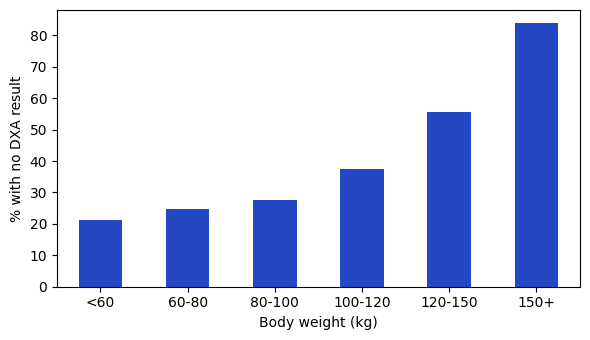

In [9]:
w = df_baseline.dropna(subset=["BMXWT"]).copy()
w["weight_band"] = pd.cut(w["BMXWT"], bins=[0, 60, 80, 100, 120, 150, 400],
                          labels=["<60", "60-80", "80-100", "100-120", "120-150", "150+"], right=False)
miss = w.groupby("weight_band", observed=True)["DXA_COMPLETE"].agg(
    n="size", pct_no_dxa=lambda s: round((~s).mean() * 100, 1))
print(miss)

ax = miss["pct_no_dxa"].plot.bar(color="#2347c5", figsize=(6, 3.5), rot=0)
ax.set_xlabel("Body weight (kg)")
ax.set_ylabel("% with no DXA result")
plt.tight_layout()
plt.show()

ผลตรงกับที่เดา กลุ่มที่ไม่มีผล DXA หนักกว่าเฉลี่ยราว 12 kg (91.97 เทียบ 79.99), BMI สูงกว่า (32.10 เทียบ 28.77) และรอบเอวใหญ่กว่า (104.8 เทียบ 96.2 cm) ส่วนอายุกับเพศใกล้เคียงกัน พอแยกตามน้ำหนัก ช่วง 120-150 kg ไม่มีผลถึง 55% และ 150 kg ขึ้นไปถึง 84%

แปลว่าไม่ได้ขาดแบบสุ่ม ถ้าตัดคนที่ไม่มีผลทิ้ง ข้อมูลที่เหลือจะเอนไปทางคนตัวเล็ก ตอนทดสอบ model เลยต้องแยกทดสอบกับคนน้ำหนักมากด้วย

## 7. ชุดข้อมูลสำหรับสร้าง model

รวมขั้นตอนทั้งหมดไว้ใน `src/real_label.py` แล้ว `rl.build()` จะต่อไฟล์ที่เหลือ (อาหาร การนอน กิจกรรม) คำนวณมวลกล้ามเนื้อกับ Fat % จาก DXA และตัดคนที่ข้อมูลไม่ครบ ตอน train ก็ใช้ชุดเดียวกันนี้

In [10]:
import sys
sys.path.insert(0, "../src")
import real_label as rl

df_dxa_complete = df_baseline[df_baseline["DXA_COMPLETE"]].copy()
data, n_adults = rl.build()
print("ผู้ใหญ่ 18-59 ปี           ", n_adults)
print("มีไขมันและ lean ครบ        ", len(df_dxa_complete))
print("ชุดที่ใช้ train/test (final)", len(data))

gone = df_dxa_complete[~df_dxa_complete["SEQN"].isin(data["SEQN"])]
print("\nหายไป", len(gone), "คน เพราะขาดค่าวัดร่างกาย (ตารางด้านล่าง) หรือมวลกล้ามเนื้อรายส่วนจาก DXA")
print(gone[["BMXHT", "BMXWT"] + rl.CIRC].isna().sum())

ผู้ใหญ่ 18-59 ปี            3515
มีไขมันและ lean ครบ         2452
ชุดที่ใช้ train/test (final) 2310

หายไป 142 คน เพราะขาดค่าวัดร่างกาย (ตารางด้านล่าง) หรือมวลกล้ามเนื้อรายส่วนจาก DXA
BMXHT        9
BMXWT        8
BMXWAIST    23
BMXHIP      18
BMXARMC     14
BMXARML     14
BMXLEG      33
dtype: int64


Fat % คำนวณจาก ไขมัน / (ไขมัน + lean + กระดูก) × 100 โดยตัวหารคือมวลรวมที่ DXA วัดเอง ส่วนมวลกล้ามเนื้อรวมเรียก `LEAN_KG` คือเนื้อเยื่อที่ไม่ใช่ไขมันและกระดูก

In [11]:
print("correlation น้ำหนักที่ชั่ง กับ (ไขมัน + lean)", round(data["BMXWT"].corr(data["FAT_KG"] + data["LEAN_KG"]), 4))
print("\ncorrelation ของน้ำหนักกับไขมัน และ lean")
print(data[["BMXWT", "FAT_KG", "LEAN_KG"]].corr().round(3))
print()
print(data[["BMXWT", "FAT_PCT", "FAT_KG", "LEAN_KG", "ALM_KG"]].describe().round(2))

correlation น้ำหนักที่ชั่ง กับ (ไขมัน + lean) 0.9996

correlation ของน้ำหนักกับไขมัน และ lean
         BMXWT  FAT_KG  LEAN_KG
BMXWT    1.000   0.816    0.861
FAT_KG   0.816   1.000    0.409
LEAN_KG  0.861   0.409    1.000

         BMXWT  FAT_PCT   FAT_KG  LEAN_KG   ALM_KG
count  2310.00  2310.00  2310.00  2310.00  2310.00
mean     79.13    32.95    26.73    50.48    22.21
std      20.30     8.53    11.32    12.58     6.29
min      36.20    12.14     5.81    20.08     7.21
25%      64.60    26.90    18.48    40.42    17.07
50%      76.20    32.68    24.83    49.30    21.62
75%      90.98    39.92    33.00    59.03    26.64
max     176.50    56.11    82.89   105.58    55.38


น้ำหนักที่ชั่งสัมพันธ์กับไขมัน + lean สูงมาก แปลว่าค่า DXA สอดคล้องกับตาชั่ง ใช้เป็นเกณฑ์เช็กคุณภาพข้อมูลได้

## 8. เทียบองค์ประกอบร่างกายระหว่างเพศ

ใช้ Welch's t-test (ไม่ต้องสมมติว่าความแปรปรวนสองกลุ่มเท่ากัน) คู่กับ Cohen's d เพื่อดูว่าต่างกัน **มากแค่ไหน** ไม่ได้ดูแค่ p-value

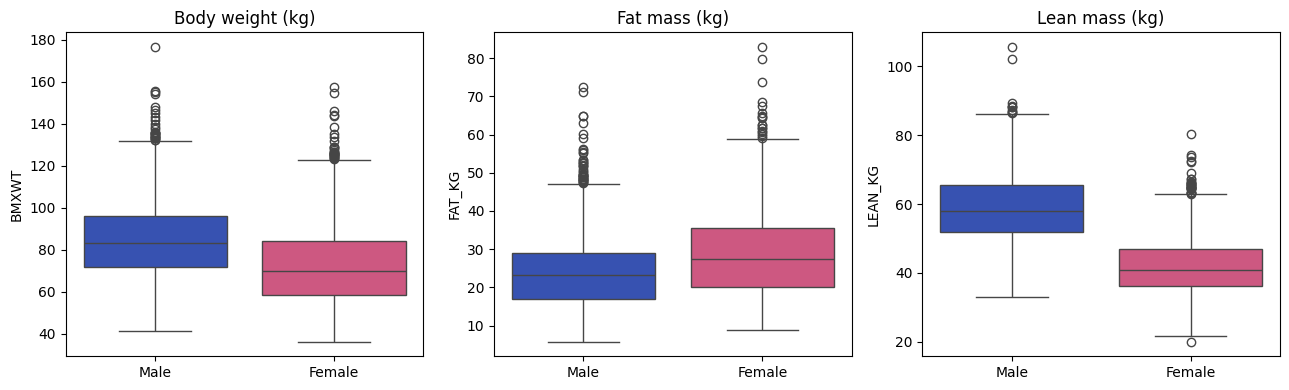

In [12]:
variables = {"BMXWT": "Body weight (kg)", "FAT_KG": "Fat mass (kg)", "LEAN_KG": "Lean mass (kg)"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (v, title) in zip(axes, variables.items()):
    sns.boxplot(data=data, x="RIAGENDR", y=v, hue="RIAGENDR",
                palette=["#2347c5", "#e0457b"], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Male", "Female"])
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [13]:
def welch(var):
    m = data.loc[data["RIAGENDR"] == 1, var].dropna()
    f = data.loc[data["RIAGENDR"] == 2, var].dropna()
    res = stats.ttest_ind(m, f, equal_var=False)
    diff = m.mean() - f.mean()
    vm, vf = m.var(ddof=1) / len(m), f.var(ddof=1) / len(f)
    se = np.sqrt(vm + vf)
    dof = (vm + vf) ** 2 / (vm ** 2 / (len(m) - 1) + vf ** 2 / (len(f) - 1))
    tc = stats.t.ppf(0.975, dof)
    pooled_sd = np.sqrt(((len(m) - 1) * m.var(ddof=1) + (len(f) - 1) * f.var(ddof=1)) / (len(m) + len(f) - 2))
    return {"variable": var, "male_mean": m.mean(), "female_mean": f.mean(), "diff": diff,
            "ci95_low": diff - tc * se, "ci95_high": diff + tc * se,
            "cohens_d": diff / pooled_sd, "t": res.statistic, "p_value": res.pvalue}

res = pd.DataFrame([welch(v) for v in variables]).set_index("variable")
out = res.drop(columns="p_value").round(3)
out["p_value"] = res["p_value"].map("{:.2e}".format)
out

,male_mean,female_mean,diff,ci95_low,ci95_high,cohens_d,t,p_value
variable,,,,,,,,
BMXWT,85.433,73.189,12.244,10.665,13.824,0.633,15.201,8.40e-50
FAT_KG,24.221,29.089,-4.868,-5.767,-3.969,-0.440,-10.617,9.68e-26
LEAN_KG,59.103,42.343,16.760,15.990,17.530,1.786,42.674,1.22e-289


ชายกับหญิงต่างกันมากที่สุดที่มวลกล้ามเนื้อ (Cohen's d ราว 1.8 ถือว่าใหญ่มาก) มากกว่าน้ำหนักและมวลไขมัน เลยใส่เพศเป็น input ของ model

## 9. ภาพรวมชุดข้อมูลสุดท้าย

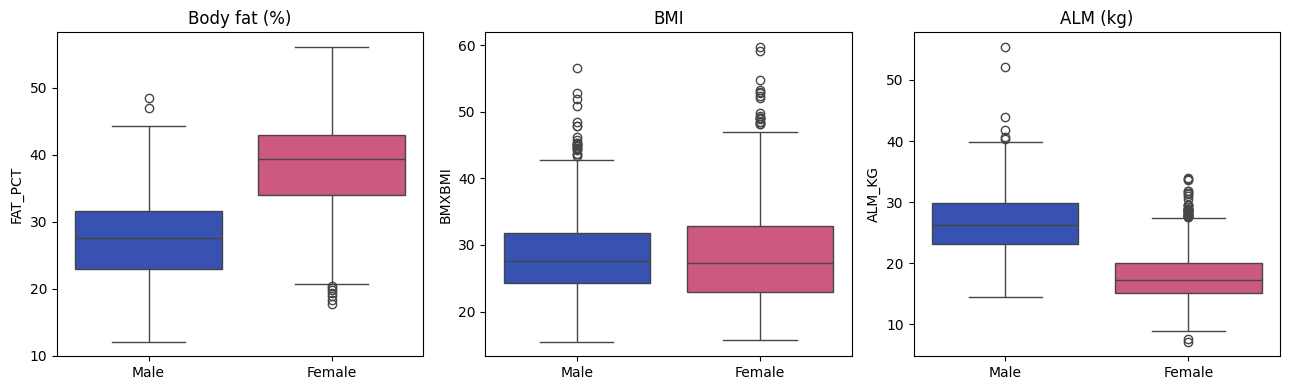

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (v, title) in zip(axes, [("FAT_PCT", "Body fat (%)"), ("BMXBMI", "BMI"), ("ALM_KG", "ALM (kg)")]):
    sns.boxplot(data=data, x="RIAGENDR", y=v, hue="RIAGENDR", palette=["#2347c5", "#e0457b"], legend=False, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Male", "Female"]); ax.set_title(title); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## สรุป

- ผู้ใหญ่ 18-59 ปีมี 3,515 คน ไขมันกับ lean ครบ 2,452 คน และเหลือ 2,310 คนที่ข้อมูลครบพอสร้าง model
- DXA ที่ขาดสัมพันธ์กับน้ำหนัก (120-150 kg ไม่มีผล 55%, 150 kg ขึ้นไป 84%) ไม่ได้ขาดแบบสุ่ม ต้องทดสอบกับคนน้ำหนักมากแยกต่างหาก
- เพศต่างกันมากที่สุดที่มวลกล้ามเนื้อ เลยใช้เพศเป็น input